In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the SCNA table
B_cells_table = pd.read_csv("B_cells_table.csv")
B_cells_table.head()
B_cells_table["AllHits"].unique()

array([nan, 'Gain_ImmuneHot', 'Loss_ImmuneCold', 'Loss_ImmuneHot',
       'Gain_ImmuneCold'], dtype=object)

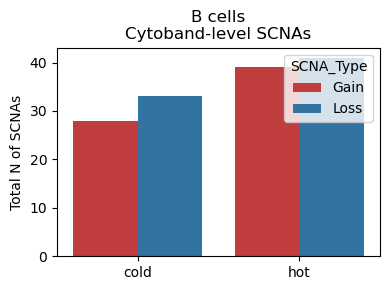

In [4]:
# Drop NA rows
B_cells_table = B_cells_table[B_cells_table["AllHits"].notna()]

# Parse AllHits column into immune status and SCNA type
B_cells_table["Immune_Status"] = B_cells_table["AllHits"].apply(lambda x: "cold" if "Cold" in x else "hot")
B_cells_table["SCNA_Type"] = B_cells_table["AllHits"].apply(lambda x: "Gain" if "Gain" in x else "Loss")

# Count total SCNAs
plot_B_cells_table = B_cells_table.groupby(["Immune_Status", "SCNA_Type"]).size().reset_index(name="Count")

# Plot
plt.figure(figsize=(4, 3))
sns.barplot(data=plot_B_cells_table, x="Immune_Status", y="Count", hue="SCNA_Type",
            palette={"Gain": "#d62728", "Loss": "#1f77b4"})
plt.title("B cells\nCytoband-level SCNAs")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.tight_layout()
plt.show()

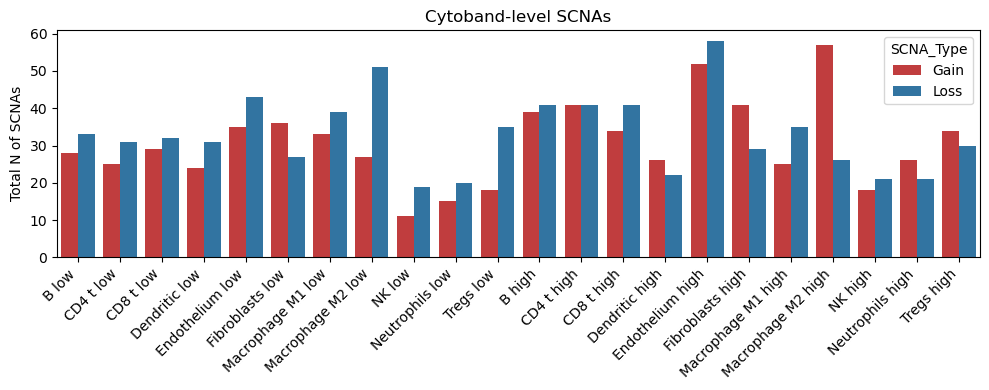

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# Define folder with CSVs
folder = "./"  # update if needed

# Automatically detect all *_table.csv files
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# Special handling rules
only_hot = ["Macrophages_M2"]
only_cold = ["Macrophages_M1"]

# Color scheme
bar_colors = {"low": "#1f77b4", "high": "#d62728"}

# Parse cell type from filename
def extract_celltype(filename):
    return os.path.basename(filename).replace("_table.csv", "")

# Format label: "B cell low", "CD4+ T high", etc.
def format_label(cell, status):
    base = cell.replace("_", " ").replace("cells", "").replace("cell", "").strip()
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Container for all rows
rows = []

# Process each cell type
for file_path in table_files:
    cell = extract_celltype(file_path)
    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]

    # Determine what to include
    include_cold = cell not in only_hot
    include_hot = cell not in only_cold

    if include_cold:
        cold_hits = df[df["AllHits"].str.contains("ImmuneCold")]
        gain = cold_hits["AllHits"].str.contains("Gain").sum()
        loss = cold_hits["AllHits"].str.contains("Loss").sum()
        rows.append({
            "CellType": format_label(cell, "cold"),
            "SCNA_Type": "Gain", "Count": gain, "Color": bar_colors["low"]
        })
        rows.append({
            "CellType": format_label(cell, "cold"),
            "SCNA_Type": "Loss", "Count": loss, "Color": bar_colors["low"]
        })

    if include_hot:
        hot_hits = df[df["AllHits"].str.contains("ImmuneHot")]
        gain = hot_hits["AllHits"].str.contains("Gain").sum()
        loss = hot_hits["AllHits"].str.contains("Loss").sum()
        rows.append({
            "CellType": format_label(cell, "hot"),
            "SCNA_Type": "Gain", "Count": gain, "Color": bar_colors["high"]
        })
        rows.append({
            "CellType": format_label(cell, "hot"),
            "SCNA_Type": "Loss", "Count": loss, "Color": bar_colors["high"]
        })

# Create DataFrame
plot_df = pd.DataFrame(rows)

# Custom x-axis order: all lows first, then highs
low_cells = [format_label(extract_celltype(f), "cold") for f in table_files if extract_celltype(f) not in only_hot]
high_cells = [format_label(extract_celltype(f), "hot") for f in table_files if extract_celltype(f) not in only_cold]
cell_order = low_cells + high_cells

# Plot
plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="CellType", y="Count", hue="SCNA_Type",
            order=cell_order, palette={"Gain": "#d62728", "Loss": "#1f77b4"})

plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Cytoband-level SCNAs")
plt.tight_layout()
plt.show()

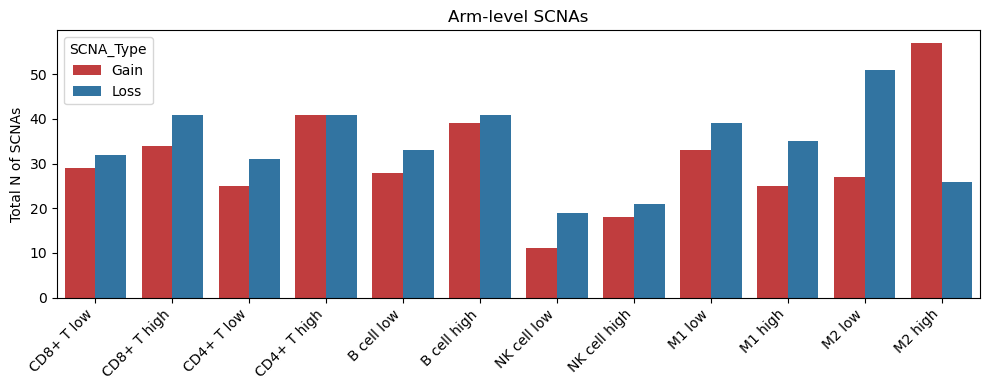

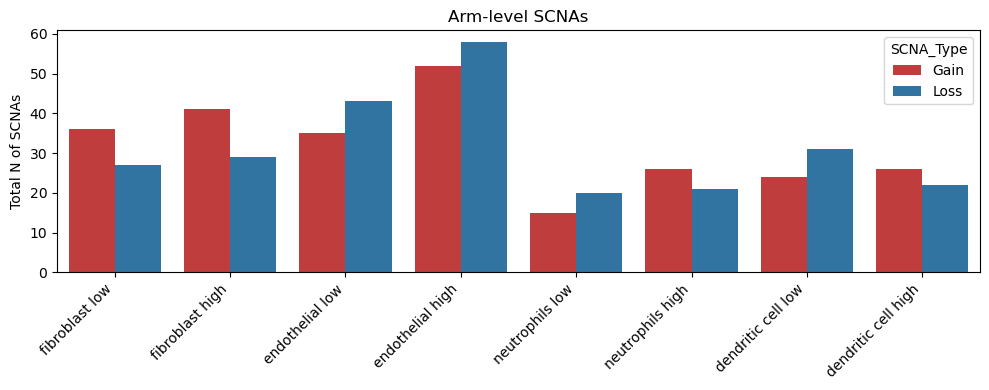

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# Folder where your *_table.csv files live
folder = "./"
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# Rename raw file base to biological plot label
rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",  # not used in figure but mapped for completeness
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast",
    "Endothelium": "endothelial",
    "Neutrophils": "neutrophils",
    "Dendritic_cells": "dendritic cell"
}

# Define color palette
bar_colors = {"low": "#1f77b4", "high": "#d62728"}

# How to label each bar
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Define Group 1 and Group 2 plotting order
group1_order = [
    "CD8+ T low", "CD8+ T high", "CD4+ T low", "CD4+ T high", 
    "B cell low", "B cell high",
    "NK cell low", "NK cell high", "M1 low", "M1 high",
    "M2 low", "M2 high"
]

group2_order = [
    "fibroblast low", "fibroblast high", "endothelial low", "endothelial high",
    "neutrophils low", "neutrophils high", "dendritic cell low", "dendritic cell high"
]

# Store SCNA counts per cell type × immune status
plot_data = []

for file_path in table_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue  # skip unexpected files

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]

    # Immune cold
    df_cold = df[df["AllHits"].str.contains("ImmuneCold")]
    gain_cold = df_cold["AllHits"].str.contains("Gain").sum()
    loss_cold = df_cold["AllHits"].str.contains("Loss").sum()
    label_cold = format_label(raw, "cold")
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Gain", "Count": gain_cold})
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Loss", "Count": loss_cold})

    # Immune hot
    df_hot = df[df["AllHits"].str.contains("ImmuneHot")]
    gain_hot = df_hot["AllHits"].str.contains("Gain").sum()
    loss_hot = df_hot["AllHits"].str.contains("Loss").sum()
    label_hot = format_label(raw, "hot")
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Gain", "Count": gain_hot})
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Loss", "Count": loss_hot})

# Create plotting DataFrame
plot_df = pd.DataFrame(plot_data)

# Plot Group 1
plt.figure(figsize=(10, 4))
sns.barplot(
    data=plot_df[plot_df["CellType"].isin(group1_order)],
    x="CellType", y="Count", hue="SCNA_Type",
    order=group1_order,
    palette={"Gain": "#d62728", "Loss": "#1f77b4"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Arm-level SCNAs")
plt.tight_layout()
plt.savefig("fig4a_arm.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Plot Group 2
plt.figure(figsize=(10, 4))
sns.barplot(
    data=plot_df[plot_df["CellType"].isin(group2_order)],
    x="CellType", y="Count", hue="SCNA_Type",
    order=group2_order,
    palette={"Gain": "#d62728", "Loss": "#1f77b4"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Arm-level SCNAs")
plt.tight_layout()
plt.savefig("fig4b_arm.pdf", format="pdf", bbox_inches="tight")
plt.show()



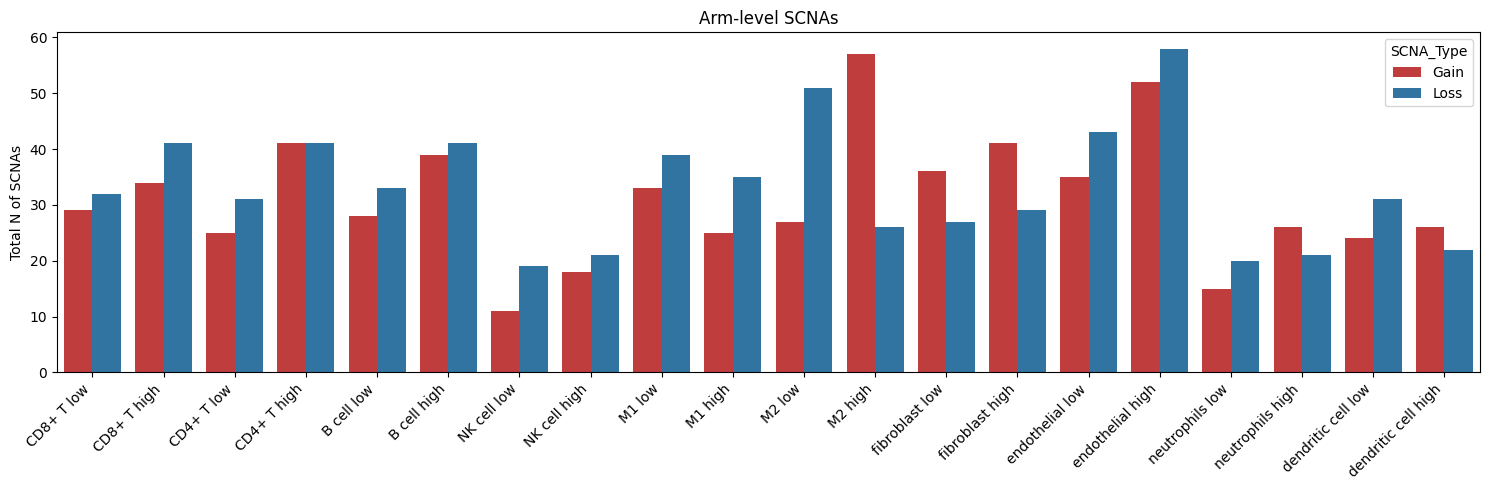

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# Folder where your *_table.csv files live
folder = "./"
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# Rename raw file base to biological plot label
rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",  # now included in plot
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast",
    "Endothelium": "endothelial",
    "Neutrophils": "neutrophils",
    "Dendritic_cells": "dendritic cell"
}

# How to label each bar
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Combined plotting order with CD4+ T cells included
celltype_order = [
    "CD8+ T low", "CD8+ T high",
    "CD4+ T low", "CD4+ T high",
    "B cell low", "B cell high",
    "NK cell low", "NK cell high",
    "M1 low", "M1 high", "M2 low", "M2 high",
    "fibroblast low", "fibroblast high",
    "endothelial low", "endothelial high",
    "neutrophils low", "neutrophils high",
    "dendritic cell low", "dendritic cell high"
]

# Store SCNA counts per cell type × immune status
plot_data = []

for file_path in table_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue  # skip unexpected files

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]

    # Immune cold
    df_cold = df[df["AllHits"].str.contains("ImmuneCold")]
    gain_cold = df_cold["AllHits"].str.contains("Gain").sum()
    loss_cold = df_cold["AllHits"].str.contains("Loss").sum()
    label_cold = format_label(raw, "cold")
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Gain", "Count": gain_cold})
    plot_data.append({"CellType": label_cold, "SCNA_Type": "Loss", "Count": loss_cold})

    # Immune hot
    df_hot = df[df["AllHits"].str.contains("ImmuneHot")]
    gain_hot = df_hot["AllHits"].str.contains("Gain").sum()
    loss_hot = df_hot["AllHits"].str.contains("Loss").sum()
    label_hot = format_label(raw, "hot")
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Gain", "Count": gain_hot})
    plot_data.append({"CellType": label_hot, "SCNA_Type": "Loss", "Count": loss_hot})

# Create plotting DataFrame
plot_df = pd.DataFrame(plot_data)

# === Unified Plot with CD4+ T ===
plt.figure(figsize=(15, 5))
sns.barplot(
    data=plot_df[plot_df["CellType"].isin(celltype_order)],
    x="CellType", y="Count", hue="SCNA_Type",
    order=celltype_order,
    palette={"Gain": "#d62728", "Loss": "#1f77b4"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Arm-level SCNAs")
plt.tight_layout()
# plt.savefig("fig4_combined_arm_with_CD4.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [2]:
# Total SCNAs across all cell types and immune states
total_summary = plot_df.groupby("SCNA_Type")["Count"].sum().reset_index()
print("Total SCNA counts:")
print(total_summary)

Total SCNA counts:
  SCNA_Type  Count
0      Gain    622
1      Loss    661


In [4]:
# SCNA counts grouped by CellType (low/high) and SCNA_Type (Gain/Loss)
scna_counts_detailed = plot_df.groupby(["CellType", "SCNA_Type"])["Count"].sum().reset_index()

# Print the detailed count table
print("SCNA counts per immune cell type × condition × SCNA type:")
print(scna_counts_detailed)

SCNA counts per immune cell type × condition × SCNA type:
               CellType SCNA_Type  Count
0           B cell high      Gain     39
1           B cell high      Loss     41
2            B cell low      Gain     28
3            B cell low      Loss     33
4           CD4+ T high      Gain     41
5           CD4+ T high      Loss     41
6            CD4+ T low      Gain     25
7            CD4+ T low      Loss     31
8           CD8+ T high      Gain     34
9           CD8+ T high      Loss     41
10           CD8+ T low      Gain     29
11           CD8+ T low      Loss     32
12              M1 high      Gain     25
13              M1 high      Loss     35
14               M1 low      Gain     33
15               M1 low      Loss     39
16              M2 high      Gain     57
17              M2 high      Loss     26
18               M2 low      Gain     27
19               M2 low      Loss     51
20         NK cell high      Gain     18
21         NK cell high      Loss     21

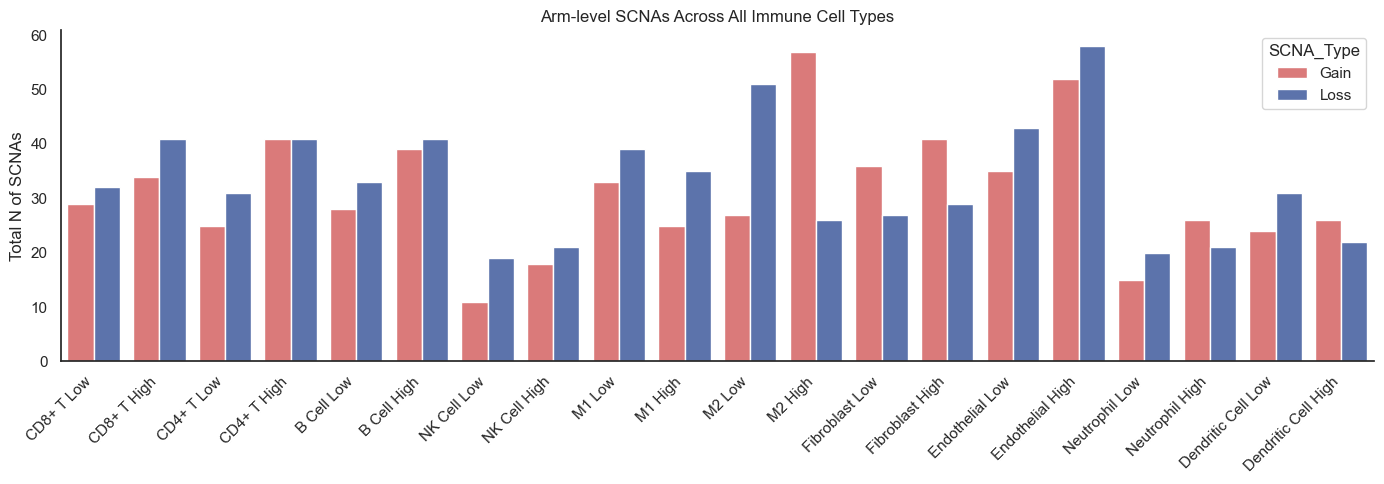

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
folder = "./"                        # folder with *arm*-level *_table.csv files
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# display names (capital-cased, same as cytoband plot)
rename_map = {
    "CD8_tcells"     : "CD8+ T",
    "CD4_tcells"     : "CD4+ T",
    "B_cells"        : "B Cell",
    "NK_cells"       : "NK Cell",
    "Macrophage_M1"  : "M1",
    "Macrophage_M2"  : "M2",
    "Fibroblasts"    : "Fibroblast",
    "Endothelium"    : "Endothelial",
    "Neutrophils"    : "Neutrophil",
    "Dendritic_cells": "Dendritic Cell",
}

# x-axis order (matches cytoband figure)
celltype_order = [
    "CD8+ T Low", "CD8+ T High",
    "CD4+ T Low", "CD4+ T High",
    "B Cell Low", "B Cell High",
    "NK Cell Low", "NK Cell High",
    "M1 Low", "M1 High", "M2 Low", "M2 High",
    "Fibroblast Low", "Fibroblast High",
    "Endothelial Low", "Endothelial High",
    "Neutrophil Low", "Neutrophil High",
    "Dendritic Cell Low", "Dendritic Cell High",
]

# colour palette (same everywhere)
palette = {"Gain": "#EA6A6A", "Loss": "#4F6DB8"}

# helper for consistent labels
def format_label(raw_name: str, status: str) -> str:
    base   = rename_map.get(raw_name, raw_name.replace("_", " ").title())
    suffix = "Low" if status == "cold" else "High"
    return f"{base} {suffix}"

# ── COLLECT PLOT DATA ─────────────────────────────────────────────────────────
plot_rows = []

for fp in table_files:
    raw = os.path.basename(fp).replace("_table.csv", "")
    if raw not in rename_map:
        continue  # skip unexpected files

    df = pd.read_csv(fp)
    df = df[df["AllHits"].notna()]

    # immune-cold
    df_cold = df[df["AllHits"].str.contains("ImmuneCold")]
    plot_rows.extend([
        {"CellType": format_label(raw, "cold"), "SCNA_Type": "Gain",
         "Count": df_cold["AllHits"].str.contains("Gain").sum()},
        {"CellType": format_label(raw, "cold"), "SCNA_Type": "Loss",
         "Count": df_cold["AllHits"].str.contains("Loss").sum()},
    ])

    # immune-hot
    df_hot = df[df["AllHits"].str.contains("ImmuneHot")]
    plot_rows.extend([
        {"CellType": format_label(raw, "hot"), "SCNA_Type": "Gain",
         "Count": df_hot["AllHits"].str.contains("Gain").sum()},
        {"CellType": format_label(raw, "hot"), "SCNA_Type": "Loss",
         "Count": df_hot["AllHits"].str.contains("Loss").sum()},
    ])

plot_df = pd.DataFrame(plot_rows)

sns.set_theme(style="white")  

# ── PLOT ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
ax = sns.barplot(
    data   = plot_df,
    x      = "CellType",
    y      = "Count",
    hue    = "SCNA_Type",
    order  = celltype_order,
    palette= palette
)
ax.grid(False)                      # remove any residual Matplotlib grid lines
sns.despine()                       # optional: drop top/right spines
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.xlabel("")
plt.title("Arm-level SCNAs Across All Immune Cell Types")
plt.tight_layout()
plt.savefig("fig4_combined_arm.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Tumor types 

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_93062/284711461.py:109: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


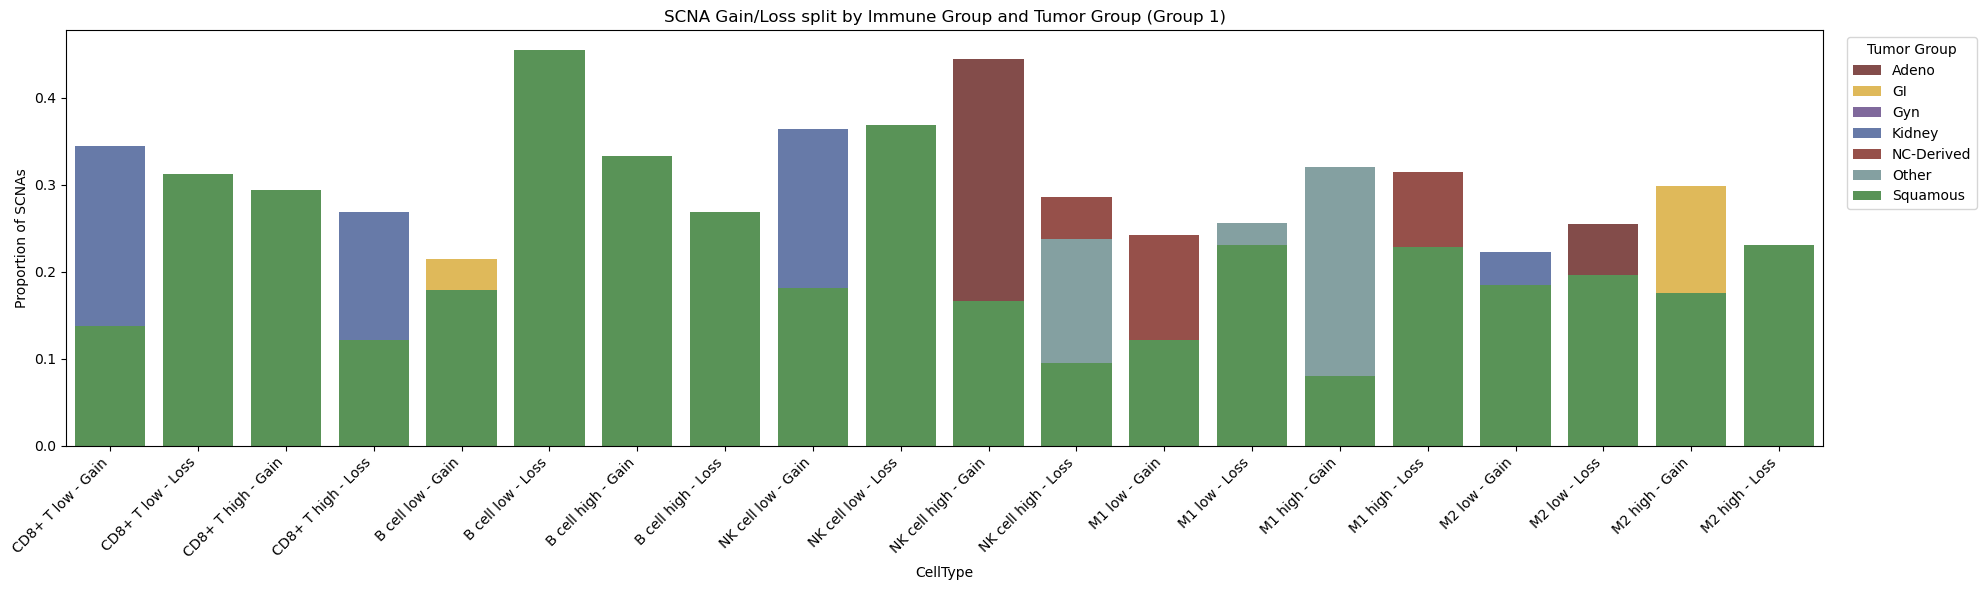

/var/folders/6l/7vr5y5g91fb54d47lr02cq2h0000gn/T/ipykernel_93062/284711461.py:128: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


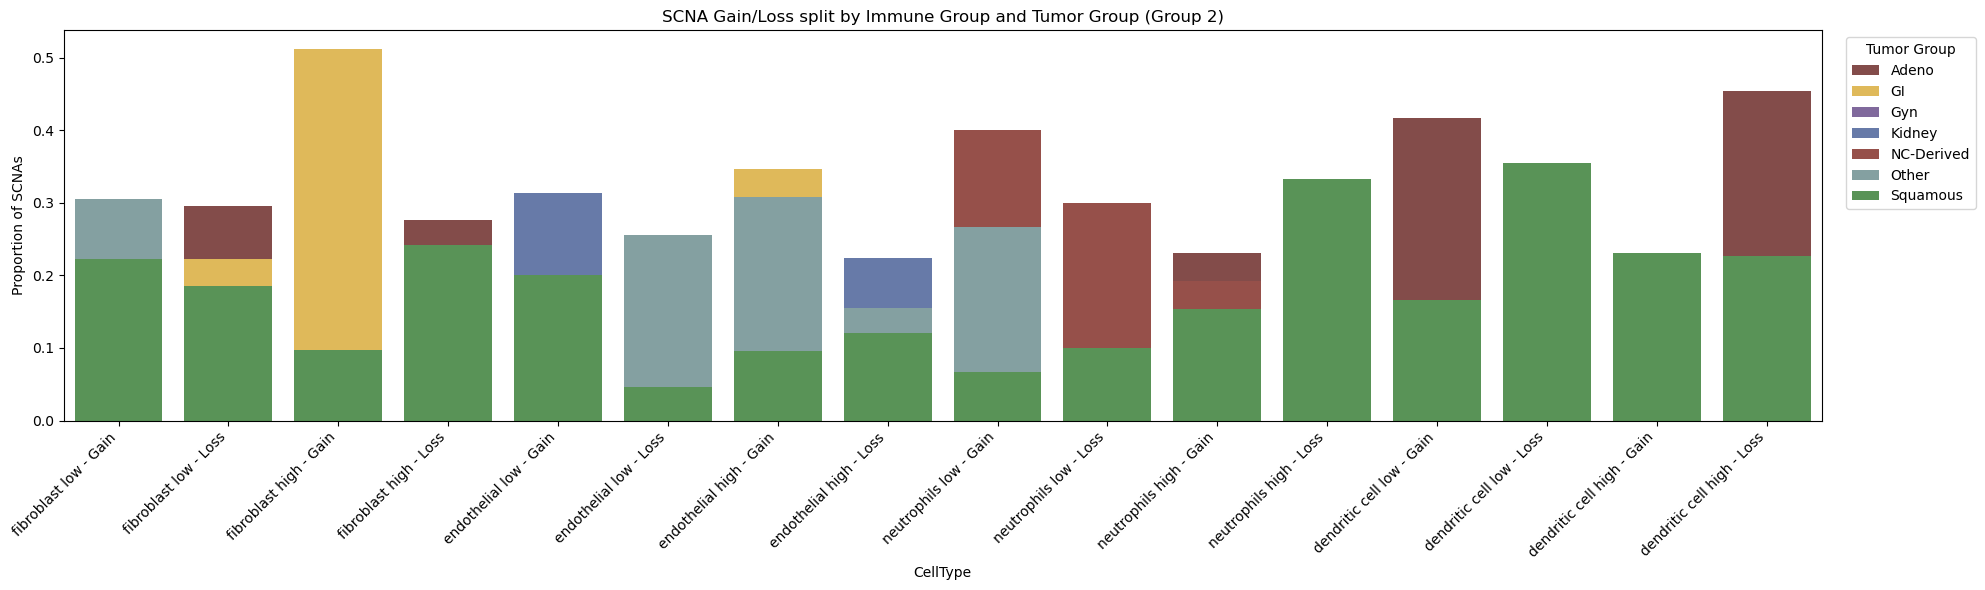

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# === File Loading ===
folder = "./"
table_files = sorted(glob(os.path.join(folder, "*_table.csv")))

# === Immune Cell Name Mapping ===
rename_map = {
    "CD8_tcells": "CD8+ T", "CD4_tcells": "CD4+ T",
    "B_cells": "B cell", "NK_cells": "NK cell",
    "Macrophage_M1": "M1", "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast", "Endothelium": "endothelial",
    "Neutrophils": "neutrophils", "Dendritic_cells": "dendritic cell"
}

# === Tumor Type to Group Mapping ===
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", 
    "CESC": "Squamous", "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "BLCA": "Squamous", "ESCA.SC": "Squamous",
    "BRCA.neg": "Adeno", "BRCA.pos": "Adeno", "PRAD": "Adeno", "LUAD": "Adeno", "LIHC": "Adeno", 
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived", 
    "ACC": "Other", "MESO": "Other", "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# === Tumor Group Color Palette (from heatmap legend) ===
tumor_group_palette = {
    "Adeno": "#8c4340",
    "GI": "#f5c344",
    "Gyn": "#7f61a4",
    "Kidney": "#5c76b3",
    "NC-Derived": "#a3453d",
    "Other": "#7fa5a6",
    "Squamous": "#4f9d4d"
}

# === Helper to Label Bars ===
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# === Cell Type Groups ===
group1 = ["CD8+ T", "B cell", "NK cell", "M1", "M2"]
group2 = ["fibroblast", "endothelial", "neutrophils", "dendritic cell"]
immune_statuses = [("ImmuneCold", "low"), ("ImmuneHot", "high")]

# === SCNA Counting Loop ===
plot_data = []

for file_path in table_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue

    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status_label in immune_statuses:
        df_status = df[df["AllHits"].str.contains(immune_tag)]

        for tumor_group in df_status["TumorGroup"].dropna().unique():
            df_group = df_status[df_status["TumorGroup"] == tumor_group]
            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()

            immune_label_gain = f"{rename_map[raw]} {status_label} - Gain"
            immune_label_loss = f"{rename_map[raw]} {status_label} - Loss"

            plot_data.append({
                "CellType": immune_label_gain,
                "TumorGroup": tumor_group,
                "Count": gain_count,
                "SCNA_Type": "Gain"
            })
            plot_data.append({
                "CellType": immune_label_loss,
                "TumorGroup": tumor_group,
                "Count": loss_count,
                "SCNA_Type": "Loss"
            })

df_plot = pd.DataFrame(plot_data)

# === Normalize to proportions ===
df_plot["Total"] = df_plot.groupby("CellType")["Count"].transform("sum")
df_plot["Proportion"] = df_plot["Count"] / df_plot["Total"]

# === Define Orderings ===
tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]
celltype_order_group1 = []
for ct in group1:
    celltype_order_group1.extend([f"{ct} low - Gain", f"{ct} low - Loss", f"{ct} high - Gain", f"{ct} high - Loss"])
celltype_order_group2 = []
for ct in group2:
    celltype_order_group2.extend([f"{ct} low - Gain", f"{ct} low - Loss", f"{ct} high - Gain", f"{ct} high - Loss"])

# === Plot Group 1 ===
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_plot[df_plot["CellType"].isin(celltype_order_group1)],
    x="CellType", y="Proportion", hue="TumorGroup",
    order=celltype_order_group1,
    hue_order=tumor_group_order,
    palette=tumor_group_palette,
    dodge=False,
    ci=None
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of SCNAs")
plt.title("SCNA Gain/Loss split by Immune Group and Tumor Group (Group 1)")
plt.legend(title="Tumor Group", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig4a_arm_tumorgroups.pdf", format="pdf", bbox_inches="tight")
plt.show()

# === Plot Group 2 ===
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_plot[df_plot["CellType"].isin(celltype_order_group2)],
    x="CellType", y="Proportion", hue="TumorGroup",
    order=celltype_order_group2,
    hue_order=tumor_group_order,
    palette=tumor_group_palette,
    dodge=False,
    ci=None
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of SCNAs")
plt.title("SCNA Gain/Loss split by Immune Group and Tumor Group (Group 2)")
plt.legend(title="Tumor Group", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig("fig4b_arm_tumorgroups.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# === Folder and rename map ===
folder = "./"  # update if needed
rename_map = {
    "CD8_tcells": "CD8+ T", "CD4_tcells": "CD4+ T",
    "B_cells": "B cell", "NK_cells": "NK cell",
    "Macrophage_M1": "M1", "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast", "Endothelium": "endothelial",
    "Neutrophils": "neutrophils", "Dendritic_cells": "dendritic cell"
}

# === Tumor type → tumor group ===
tumor_group_map = {
    "UCEC.MSI": "Gyn", "UCEC.MSS": "Gyn", "OV": "Gyn", "CESC": "Gyn",
    "LUSC": "Squamous", "HNSC.HPVneg": "Squamous", "ESCA.SC": "Squamous",
    "BLCA": "NC-Derived", "BRCA.neg": "NC-Derived", "BRCA.pos": "NC-Derived", "PRAD": "NC-Derived",
    "GBM": "NC-Derived", "LGG": "NC-Derived", "SKCM": "NC-Derived", "UVM": "NC-Derived",
    "LUAD": "Adeno", "LIHC": "Adeno", "ACC": "Adeno", "MESO": "Adeno",
    "COADREAD.MSI": "GI", "COADREAD.MSS": "GI", "ESCA.AD": "GI", "STAD": "GI", "PAAD": "GI",
    "KICH": "Kidney", "KIRC": "Kidney", "KIRP": "Kidney",
    "PCPG": "Other", "SARC": "Other", "TGCT": "Other", "UCS": "Other"
}

# === Color palette from legend ===
tumor_group_palette = {
    "Adeno": "#8c4340",
    "GI": "#f5c344",
    "Gyn": "#7f61a4",
    "Kidney": "#5c76b3",
    "NC-Derived": "#a3453d",
    "Other": "#7fa5a6",
    "Squamous": "#4f9d4d"
}

# === Plotting groups ===
group1 = ["CD8+ T", "B cell", "NK cell", "M1", "M2"]
group2 = ["fibroblast", "endothelial", "neutrophils", "dendritic cell"]
immune_statuses = [("ImmuneCold", "low"), ("ImmuneHot", "high")]

def format_label(raw, status):
    base = rename_map.get(raw, raw)
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

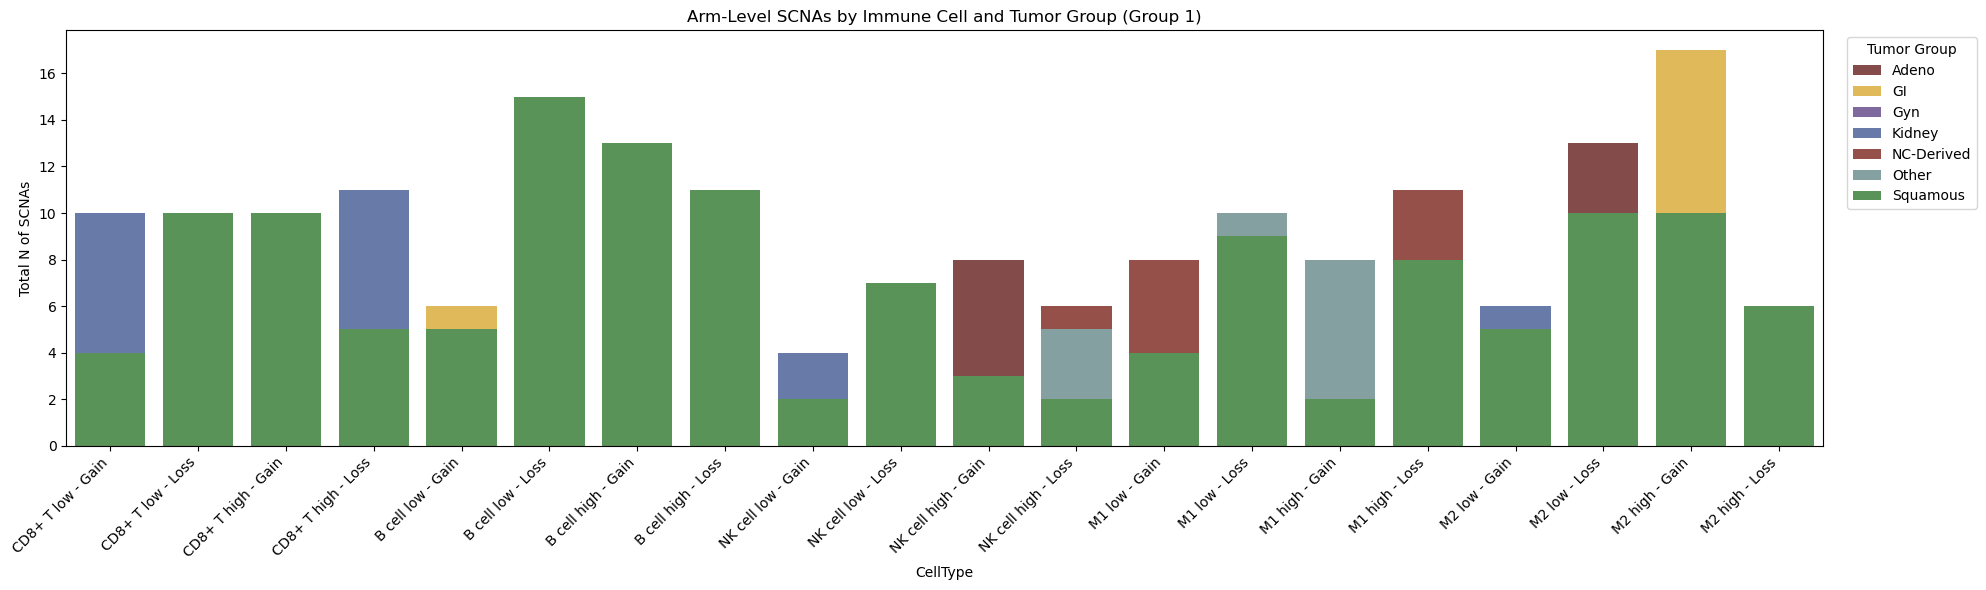

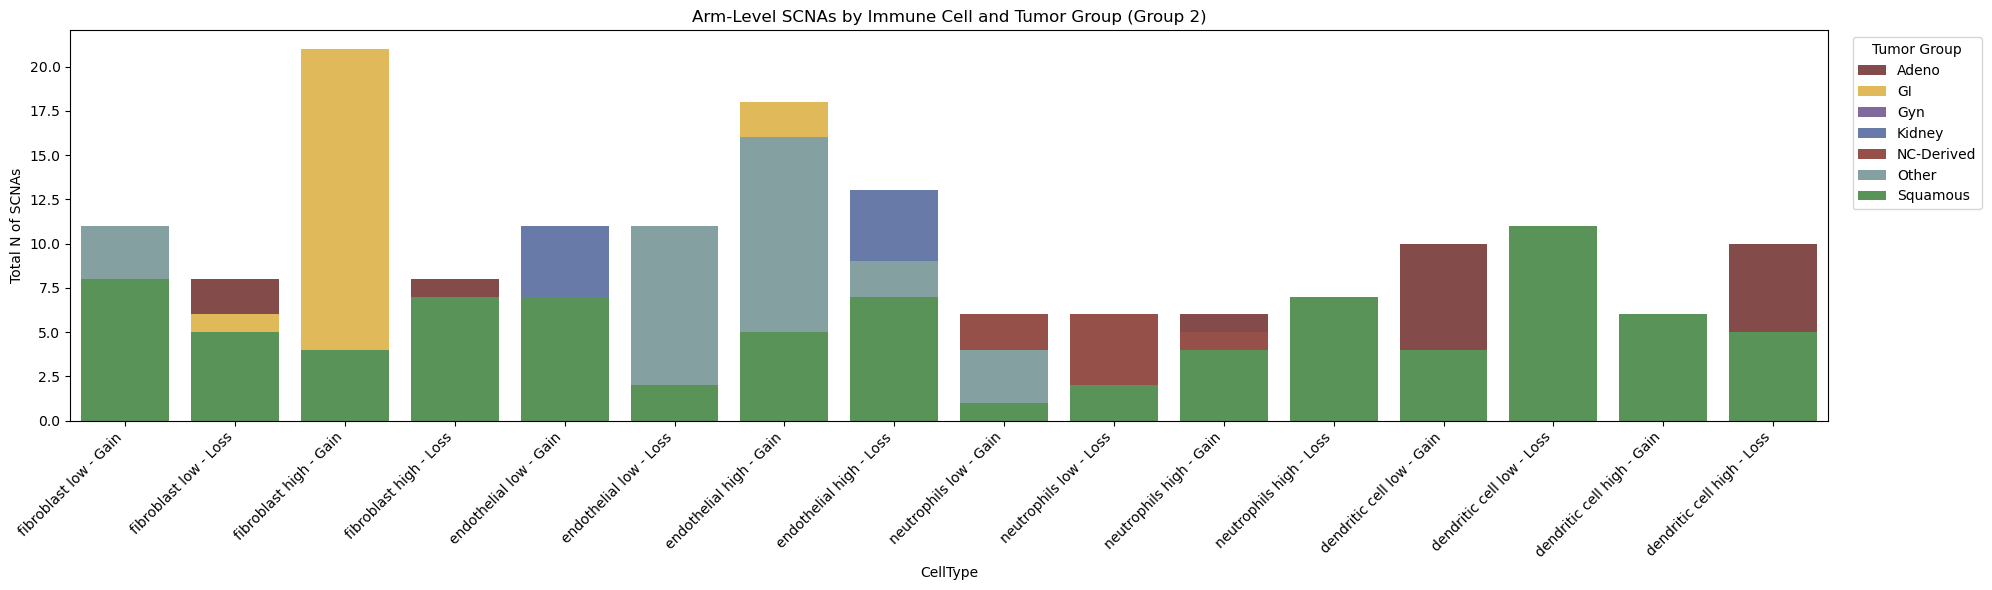

In [11]:
# === Load arm-level files ===
arm_files = sorted(glob(os.path.join(folder, "*_table.csv")))  # arm-level has no special prefix

plot_data_arm = []

for file_path in arm_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue
    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue
    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status_label in immune_statuses:
        df_status = df[df["AllHits"].str.contains(immune_tag)]
        for tumor_group in df_status["TumorGroup"].dropna().unique():
            df_group = df_status[df_status["TumorGroup"] == tumor_group]
            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()

            plot_data_arm.append({
                "CellType": f"{rename_map[raw]} {status_label} - Gain",
                "TumorGroup": tumor_group,
                "Count": gain_count
            })
            plot_data_arm.append({
                "CellType": f"{rename_map[raw]} {status_label} - Loss",
                "TumorGroup": tumor_group,
                "Count": loss_count
            })

df_arm = pd.DataFrame(plot_data_arm)

# === Plotting
tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]
celltype_order_group1 = [f"{ct} {s} - {t}" for ct in group1 for s in ["low", "high"] for t in ["Gain", "Loss"]]
celltype_order_group2 = [f"{ct} {s} - {t}" for ct in group2 for s in ["low", "high"] for t in ["Gain", "Loss"]]

# --- Group 1 ARM ---
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_arm[df_arm["CellType"].isin(celltype_order_group1)],
    x="CellType", y="Count", hue="TumorGroup",
    order=celltype_order_group1,
    hue_order=tumor_group_order,
    palette=tumor_group_palette,
    dodge=False
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.title("Arm-Level SCNAs by Immune Cell and Tumor Group (Group 1)")
plt.legend(title="Tumor Group", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Group 2 ARM ---
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_arm[df_arm["CellType"].isin(celltype_order_group2)],
    x="CellType", y="Count", hue="TumorGroup",
    order=celltype_order_group2,
    hue_order=tumor_group_order,
    palette=tumor_group_palette,
    dodge=False
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total N of SCNAs")
plt.title("Arm-Level SCNAs by Immune Cell and Tumor Group (Group 2)")
plt.legend(title="Tumor Group", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob

# === CONFIGURATION ===
folder = "./"  # Path to *_table.csv files
arm_files = sorted(glob(os.path.join(folder, "*_table.csv")))

rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast",
    "Endothelium": "endothelial",
    "Neutrophils": "neutrophils",
    "Dendritic_cells": "dendritic cell"
}

# Order for x-axis (combined Group 1 and 2)
celltype_order_all = [
    "CD8+ T low", "CD8+ T high", "B cell low", "B cell high",
    "NK cell low", "NK cell high", "M1 low", "M1 high",
    "M2 low", "M2 high", "fibroblast low", "fibroblast high",
    "endothelial low", "endothelial high", "neutrophils low", "neutrophils high",
    "dendritic cell low", "dendritic cell high"
]

# Format label
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Tumor group mapping (update as needed)
tumor_group_map = {
    "OV": "Gyn", "UCEC": "Gyn", "CESC": "Gyn",
    "KIRC": "Kidney", "KIRP": "Kidney", "KICH": "Kidney",
    "LUAD": "Adeno", "LUSC": "Squamous", "ESCA": "Other",
    "STAD": "GI", "COAD": "GI", "READ": "GI",
    "SKCM": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "HNSC": "Squamous", "BLCA": "Other", "PAAD": "GI"
}

# Tumor groups to plot
tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]

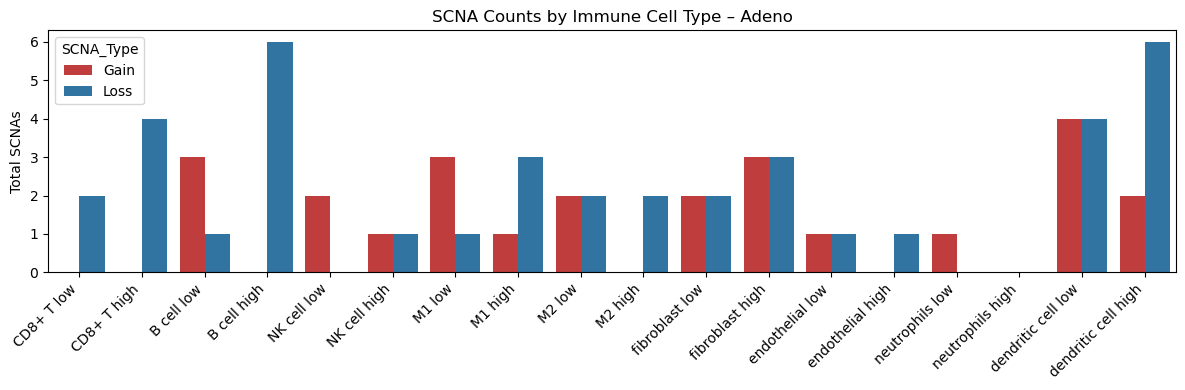

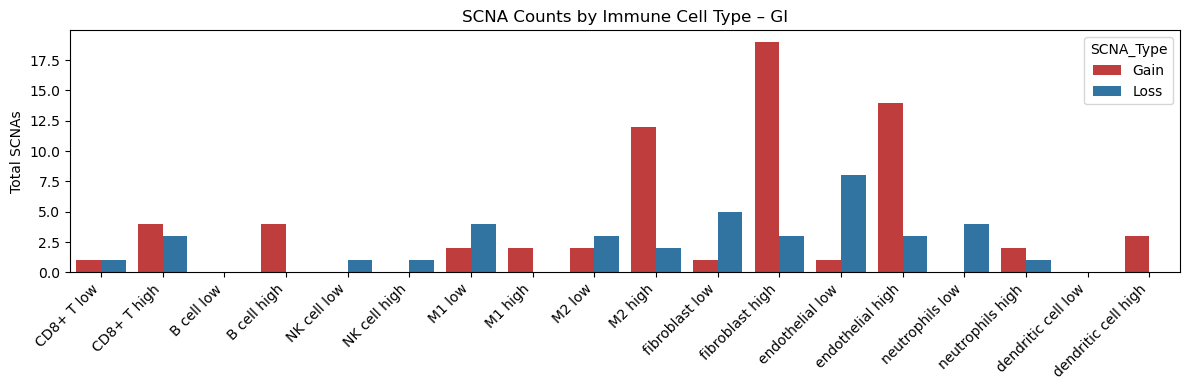

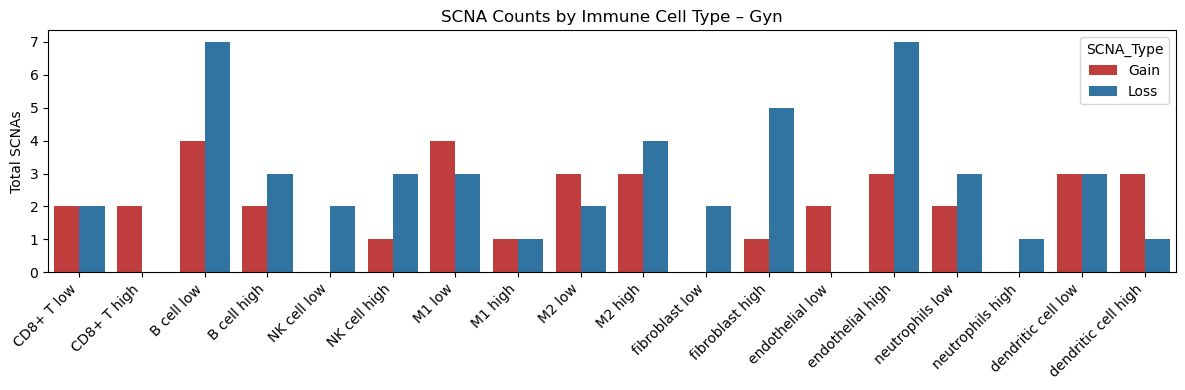

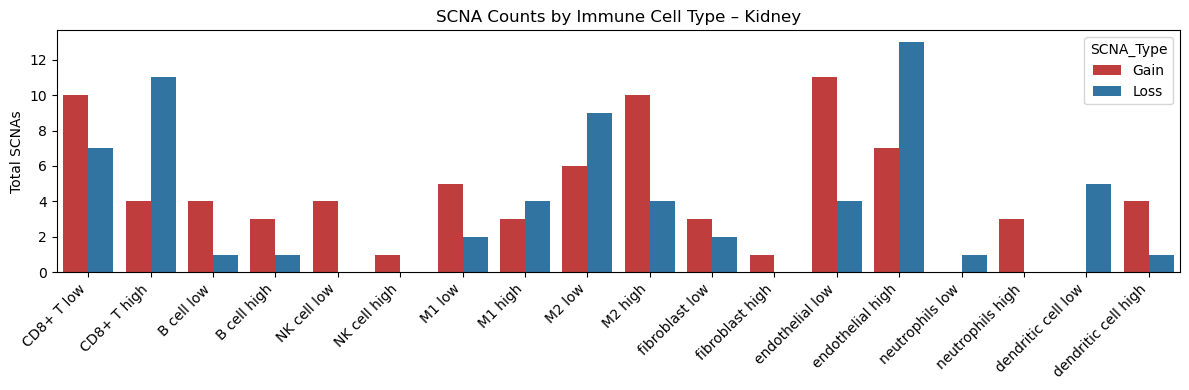

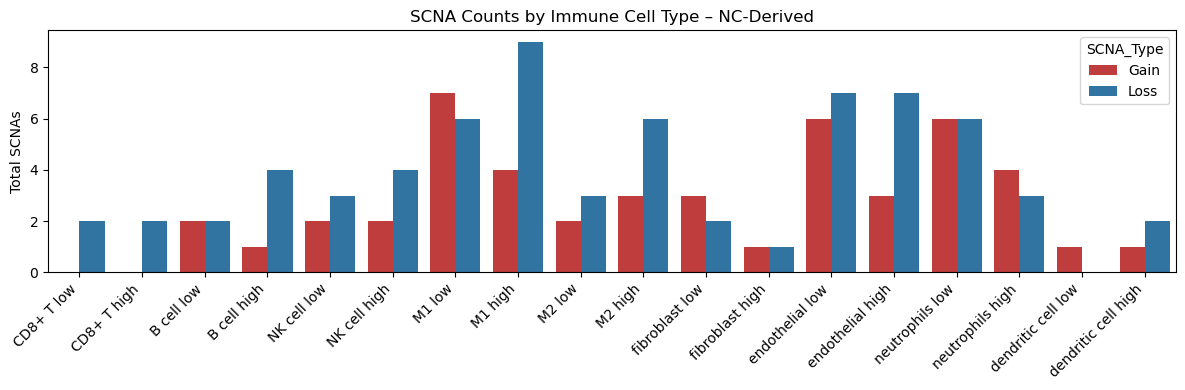

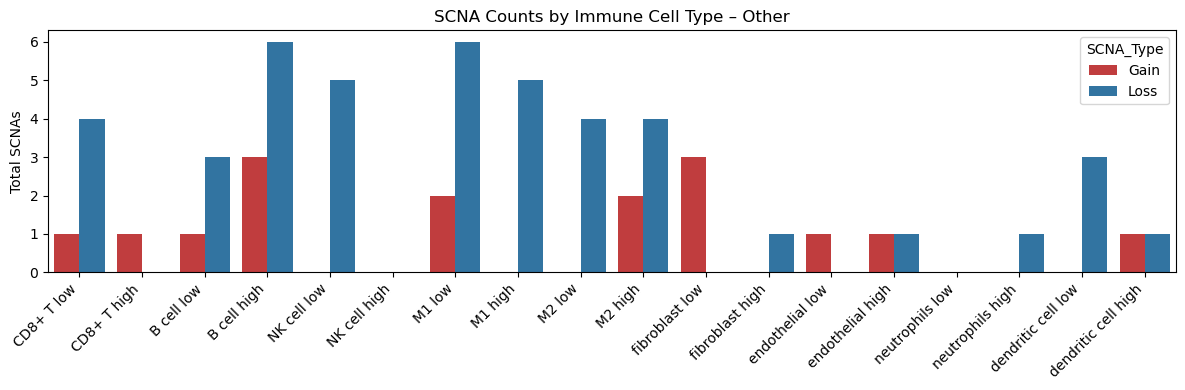

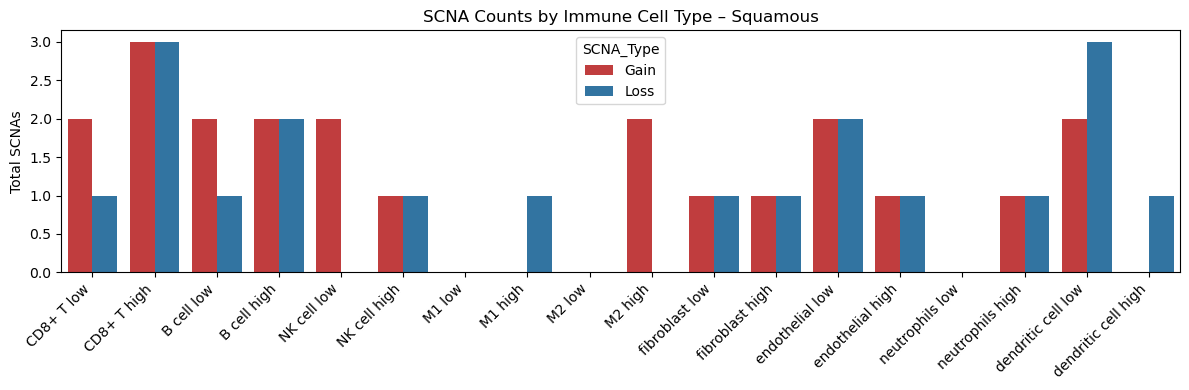

In [1]:


# === DATA EXTRACTION ===
plot_data = []

for file_path in arm_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue
    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status in [("ImmuneCold", "cold"), ("ImmuneHot", "hot")]:
        df_sub = df[df["AllHits"].str.contains(immune_tag)]
        label = format_label(raw, status)
        for tumor_group in df_sub["TumorGroup"].dropna().unique():
            df_group = df_sub[df_sub["TumorGroup"] == tumor_group]
            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()
            plot_data.append({"TumorGroup": tumor_group, "CellType": label, "SCNA_Type": "Gain", "Count": gain_count})
            plot_data.append({"TumorGroup": tumor_group, "CellType": label, "SCNA_Type": "Loss", "Count": loss_count})

df_plot = pd.DataFrame(plot_data)

# === PLOT ONE GRAPH PER TUMOR GROUP ===
for tumor in tumor_group_order:
    plt.figure(figsize=(12, 4))
    data_sub = df_plot[df_plot["TumorGroup"] == tumor]

    sns.barplot(
        data=data_sub,
        x="CellType", y="Count", hue="SCNA_Type",
        order=celltype_order_all,
        palette={"Gain": "#d62728", "Loss": "#1f77b4"}
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"SCNA Counts by Immune Cell Type – {tumor}")
    plt.ylabel("Total SCNAs")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(f"SCNA_Immune_{tumor}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [3]:
# === HELPER FUNCTION TO FORMAT CELL TYPE LABELS ===
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# === COLLECT COUNTS BY TUMOR GROUP ===
counts_by_group = {}

for file_path in arm_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue

    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status in [("ImmuneCold", "cold"), ("ImmuneHot", "hot")]:
        df_sub = df[df["AllHits"].str.contains(immune_tag)]
        label = format_label(raw, status)

        for tumor_group in df_sub["TumorGroup"].dropna().unique():
            df_group = df_sub[df_sub["TumorGroup"] == tumor_group]

            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()

            key = (tumor_group, label)

            if key not in counts_by_group:
                counts_by_group[key] = {"Gain": 0, "Loss": 0}

            counts_by_group[key]["Gain"] += gain_count
            counts_by_group[key]["Loss"] += loss_count

# === PRINT RESULTS BY TUMOR GROUP ===
print("TumorGroup\tCellType\tSCNA_Type\tCount")
for (tumor_group, celltype), scna_counts in sorted(counts_by_group.items()):
    print(f"{tumor_group}\t{celltype}\tGain\t{scna_counts['Gain']}")
    print(f"{tumor_group}\t{celltype}\tLoss\t{scna_counts['Loss']}")

TumorGroup	CellType	SCNA_Type	Count
Adeno	B cell high	Gain	0
Adeno	B cell high	Loss	6
Adeno	B cell low	Gain	3
Adeno	B cell low	Loss	1
Adeno	CD4+ T high	Gain	0
Adeno	CD4+ T high	Loss	3
Adeno	CD4+ T low	Gain	1
Adeno	CD4+ T low	Loss	0
Adeno	CD8+ T high	Gain	0
Adeno	CD8+ T high	Loss	4
Adeno	CD8+ T low	Gain	0
Adeno	CD8+ T low	Loss	2
Adeno	M1 high	Gain	1
Adeno	M1 high	Loss	3
Adeno	M1 low	Gain	3
Adeno	M1 low	Loss	1
Adeno	M2 high	Gain	0
Adeno	M2 high	Loss	2
Adeno	M2 low	Gain	2
Adeno	M2 low	Loss	2
Adeno	NK cell high	Gain	1
Adeno	NK cell high	Loss	1
Adeno	NK cell low	Gain	2
Adeno	NK cell low	Loss	0
Adeno	dendritic cell high	Gain	2
Adeno	dendritic cell high	Loss	6
Adeno	dendritic cell low	Gain	4
Adeno	dendritic cell low	Loss	4
Adeno	endothelial high	Gain	0
Adeno	endothelial high	Loss	1
Adeno	endothelial low	Gain	1
Adeno	endothelial low	Loss	1
Adeno	fibroblast high	Gain	3
Adeno	fibroblast high	Loss	3
Adeno	fibroblast low	Gain	2
Adeno	fibroblast low	Loss	2
Adeno	neutrophils low	Gain	1
Adeno	neutrop

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from matplotlib.backends.backend_pdf import PdfPages

# === CONFIGURATION ===
folder = "./"  # Path to *_table.csv files
arm_files = sorted(glob(os.path.join(folder, "*_table.csv")))

rename_map = {
    "CD8_tcells": "CD8+ T",
    "CD4_tcells": "CD4+ T",
    "B_cells": "B cell",
    "NK_cells": "NK cell",
    "Macrophage_M1": "M1",
    "Macrophage_M2": "M2",
    "Fibroblasts": "fibroblast",
    "Endothelium": "endothelial",
    "Neutrophils": "neutrophils",
    "Dendritic_cells": "dendritic cell"
}

# Order for x-axis (combined Group 1 + Group 2 + CD4+ T)
celltype_order_all = [
    "CD8+ T low", "CD8+ T high",
    "CD4+ T low", "CD4+ T high",
    "B cell low", "B cell high",
    "NK cell low", "NK cell high",
    "M1 low", "M1 high", "M2 low", "M2 high",
    "fibroblast low", "fibroblast high",
    "endothelial low", "endothelial high",
    "neutrophils low", "neutrophils high",
    "dendritic cell low", "dendritic cell high"
]

# Format label
def format_label(raw, status):
    base = rename_map.get(raw, raw.replace("_", " ").replace("cells", "").replace("cell", "").strip())
    suffix = "low" if status == "cold" else "high"
    return f"{base} {suffix}"

# Tumor group mapping (update as needed)
tumor_group_map = {
    "OV": "Gyn", "UCEC": "Gyn", "CESC": "Gyn",
    "KIRC": "Kidney", "KIRP": "Kidney", "KICH": "Kidney",
    "LUAD": "Adeno", "LUSC": "Squamous", "ESCA": "Other",
    "STAD": "GI", "COAD": "GI", "READ": "GI",
    "SKCM": "NC-Derived", "GBM": "NC-Derived", "LGG": "NC-Derived",
    "HNSC": "Squamous", "BLCA": "Other", "PAAD": "GI"
}

# Tumor groups to plot
tumor_group_order = ["Adeno", "GI", "Gyn", "Kidney", "NC-Derived", "Other", "Squamous"]

# === DATA EXTRACTION ===
plot_data = []

for file_path in arm_files:
    raw = os.path.basename(file_path).replace("_table.csv", "")
    if raw not in rename_map:
        continue

    df = pd.read_csv(file_path)
    df = df[df["AllHits"].notna()]
    if "TumorType" not in df.columns:
        continue
    df["TumorGroup"] = df["TumorType"].map(tumor_group_map)

    for immune_tag, status in [("ImmuneCold", "cold"), ("ImmuneHot", "hot")]:
        df_sub = df[df["AllHits"].str.contains(immune_tag)]
        label = format_label(raw, status)
        for tumor_group in df_sub["TumorGroup"].dropna().unique():
            df_group = df_sub[df_sub["TumorGroup"] == tumor_group]
            gain_count = df_group["AllHits"].str.contains("Gain").sum()
            loss_count = df_group["AllHits"].str.contains("Loss").sum()
            plot_data.append({"TumorGroup": tumor_group, "CellType": label, "SCNA_Type": "Gain", "Count": gain_count})
            plot_data.append({"TumorGroup": tumor_group, "CellType": label, "SCNA_Type": "Loss", "Count": loss_count})

df_plot = pd.DataFrame(plot_data)

# === MULTI-PAGE PDF ===
with PdfPages("SCNA_Immune_AllTumorGroups.pdf") as pdf:
    for tumor in tumor_group_order:
        plt.figure(figsize=(14, 4))
        data_sub = df_plot[df_plot["TumorGroup"] == tumor]

        sns.barplot(
            data=data_sub,
            x="CellType", y="Count", hue="SCNA_Type",
            order=celltype_order_all,
            palette={"Gain": "#d62728", "Loss": "#1f77b4"}
        )
        plt.xticks(rotation=45, ha="right")
        plt.title(f"SCNA Counts by Immune Cell Type – {tumor}")
        plt.ylabel("Total SCNAs")
        plt.xlabel("")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

print("SCNA_Immune_AllTumorGroups.pdf")

SCNA_Immune_AllTumorGroups.pdf
